In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(7)') 

array([2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [3]:
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")
Main.include("anomalous dim\\cusp\\cusp.jl")
Main.include("anomalous dim\\non-cusp\\gammaH.jl")
Main.include("anomalous dim\\non-cusp\\gammaB.jl")
Main.include("anomalous dim\\non-cusp\\gammaS.jl")
Main.include("anomalous dim\\non-cusp\\gammav.jl")
Main.include("hard\\hard.jl")
Main.include("jet\\jet.jl")
Main.include("soft\\soft.jl")
Main.include("sigma.jl")
Main.include("error.jl")
Main.include("fixed order\\perturbation.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fit.jl")
Main.include("NP.jl")
Main.include("renormalon.jl")

<PyCall.jlwrap renormalon_MS_func>

Range Choice

In [4]:
χ_lower = 115
χ_upper = 165

Read Data

In [31]:
dataset_qua = ["OPAL", "MAC"]  

df_qua = {}

for name in dataset_qua:
    file_path = f"data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = df["STAT"]
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_qua[name] = df1

dataset_ss = ["SLD", "MARKII", "DELPHI"]  

df_ss = {}

for name in dataset_ss:
    file_path = f"data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = np.sqrt(df["STAT"]**2+df["SYS"]**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_ss[name] = df1

dataset_names = ["OPAL", "DELPHI", "MAC", "SLD", "MARKII"]    
df = df_qua
df.update(df_ss)

#---------------------------------------------------------------------------------

df_truncated = {}
χ = {}
EEC = {}
ERROR = {}

for name in dataset_names:
    df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]

    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])

Q = {}
Q["OPAL"]=91.2
Q["DELPHI"]=91.2
Q["MAC"]=29.0
Q["SLD"]=91.2
Q["MARKII"]=29.0

Define Minimization

In [32]:
import sys
def objective(params, χ, EEC, ERROR, Q, dataset_names):

    chi2 = 0
    length = 0

    for name in dataset_names:

        αs = params[0]
        Ω1 = params[1]

        xlist=χ[name]
        ylist=EEC[name]
        errlist=ERROR[name]

        residuals=[]
        l = len(xlist)
        length = length + l


        if len(params) > 2:
            parameters = params[2:]
            residuals = (Main.model(xlist=xlist, αs=αs, Q=Q[name], XLL="N3LL'", parameters=parameters, Ω1=Ω1) - ylist)/errlist #
        else:
            residuals = (Main.model(xlist=xlist, αs=αs, Q=Q[name], XLL="N3LL'", Ω1=Ω1) - ylist)/errlist #

        chi_square = np.sum(np.square(residuals))
        chi2 = chi2 + chi_square

    return chi2/length

class ProgressCallback:
    def __init__(self, χ, EEC, ERROR, Q, dataset_names):
        self.χ = χ
        self.EEC = EEC
        self.ERROR = ERROR
        self.Q = Q
        self.dataset_names = dataset_names
        self.iteration = 0
        #self.pbar = tqdm(total=200)

    def __call__(self, params):
        self.iteration += 1
        chi2_bydof = objective(params, self.χ, self.EEC, self.ERROR, self.Q, self.dataset_names)
        print(f"Iteration: {self.iteration}, Params: {params}, Chi2/dof: {chi2_bydof}")
        sys.stdout.flush()
        #self.pbar.update()

class MyBounds:
    def __init__(self, xmax, xmin):
        self.xmax = np.array(xmax)
        self.xmin = np.array(xmin)

    def __call__(self, **kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x <= self.xmax))
        tmin = bool(np.all(x >= self.xmin))
        return tmax and tmin

Test

In [33]:
objective([0.118,0.1], χ, EEC, ERROR, Q, dataset_names)

9.33720892260546

Global

In [50]:
bounds = [ [0.11  , 0.126]
          ,[0.0  , 0.2]
        # ,[-1.0 , 1.0]
        # ,[-1.0 , 1.0]
        ]

n_points = 17
n_parameters = len(bounds)

points = [np.linspace(bound[0], bound[1], n_points) for bound in bounds]
mesh = np.meshgrid(*points, indexing='ij')
params = [list(coord) for coord in zip(*(x.ravel() for x in mesh))]
print(params)

[[0.11, 0.0], [0.11, 0.03125], [0.11, 0.0625], [0.11, 0.09375], [0.11, 0.125], [0.11, 0.15625], [0.11, 0.1875], [0.11, 0.21875], [0.11, 0.25], [0.11, 0.28125], [0.11, 0.3125], [0.11, 0.34375], [0.11, 0.375], [0.11, 0.40625], [0.11, 0.4375], [0.11, 0.46875], [0.11, 0.5], [0.111, 0.0], [0.111, 0.03125], [0.111, 0.0625], [0.111, 0.09375], [0.111, 0.125], [0.111, 0.15625], [0.111, 0.1875], [0.111, 0.21875], [0.111, 0.25], [0.111, 0.28125], [0.111, 0.3125], [0.111, 0.34375], [0.111, 0.375], [0.111, 0.40625], [0.111, 0.4375], [0.111, 0.46875], [0.111, 0.5], [0.112, 0.0], [0.112, 0.03125], [0.112, 0.0625], [0.112, 0.09375], [0.112, 0.125], [0.112, 0.15625], [0.112, 0.1875], [0.112, 0.21875], [0.112, 0.25], [0.112, 0.28125], [0.112, 0.3125], [0.112, 0.34375], [0.112, 0.375], [0.112, 0.40625], [0.112, 0.4375], [0.112, 0.46875], [0.112, 0.5], [0.113, 0.0], [0.113, 0.03125], [0.113, 0.0625], [0.113, 0.09375], [0.113, 0.125], [0.113, 0.15625], [0.113, 0.1875], [0.113, 0.21875], [0.113, 0.25], [0.1

In [51]:
chi2_list = []
for parameters in tqdm(params):
    #parameters.insert(0,0.118)
    chi2_list.append(objective(parameters, χ, EEC, ERROR, Q, dataset_names))
min_chi2 = min(chi2_list)
best_params = params[chi2_list.index(min_chi2)]
print("min_chi2/dof",min_chi2,"best_params",best_params)

100%|██████████| 289/289 [11:41<00:00,  2.43s/it]

min_chi2/dof 6.939765309269116 best_params [0.123, 0.03125]


Local then hopping

In [61]:
initial_params = best_params #[0.118, 2.0]
bounds = [ [0.110  , 0.126]
          ,[-1.0   , 1.0   ]
        #  ,[0.0   , 10.0  ]
        #  ,[-10.0 , 10.0  ]  
        #  ,[-10.0 , 10.0  ]           
        ]
bounds_T = [list(t) for t in zip(*bounds)]

progress_callback = ProgressCallback(χ, EEC, ERROR, Q, dataset_names)

minimizer_kwargs = {
    "method": "L-BFGS-B",
    "bounds": bounds,
    "args": (χ, EEC, ERROR, Q, dataset_names),
    "options": {'maxiter': 100, 'disp': True},
    "callback": progress_callback
}

result = basinhopping(
    objective,
    initial_params,
    minimizer_kwargs=minimizer_kwargs,
    niter=0,
    accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
)

optimal_params = result.x
print(f"Optimal parameters: {optimal_params}")

Iteration: 1, Params: [0.12294701 0.02704609], Chi2/dof: 6.921454114004286
Iteration: 2, Params: [0.12276983 0.0315234 ], Chi2/dof: 6.915166707323282
Iteration: 3, Params: [0.12257882 0.03631033], Chi2/dof: 6.912842158807568
Iteration: 4, Params: [0.12257728 0.03634106], Chi2/dof: 6.912841990582588
Iteration: 5, Params: [0.12257728 0.03634106], Chi2/dof: 6.912841990582398
Optimal parameters: [0.12257728 0.03634106]


In [9]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000018f9ae645e0>

Plot

In [62]:
xlist = np.pi/180*np.linspace(χ_lower,χ_upper, 50)
length=len(xlist)

#optimal_params=[0.118,0.0]
αs=optimal_params[0]
Ω1=optimal_params[1]
parameters=[0.0]#optimal_params[1:]

v={}
non_singular = {}

for name in dataset_names:
    v[name] = Main.sigma_fast(Q=Q[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL="N3LL'", parameters=parameters, Ω1=Ω1)
    non_singular[name] = []
    for x in xlist:
        non_singular[name].append(Main.non_singular_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=αs, nf=5, order=2))

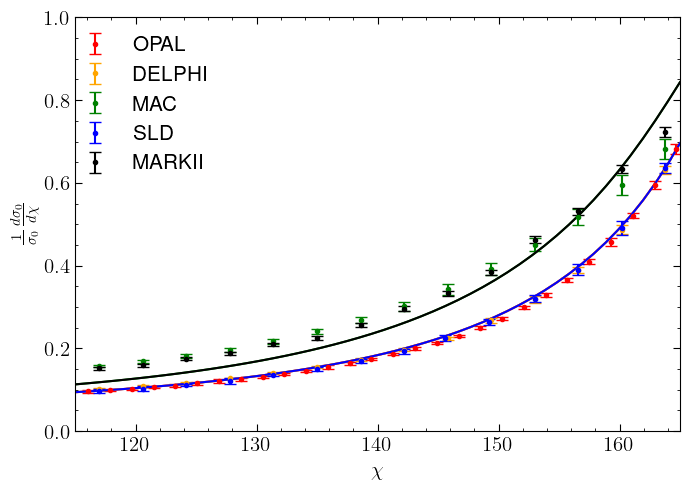

In [63]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","green","blue","black"]
i=0
for name in dataset_names:
    ax1.errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=name, color=color[i], capsize=4,markersize=3)
    ax1.plot(xlist*180/np.pi, v[name]+non_singular[name], color=color[i])
    i=i+1

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.25, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
#ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
#verticalalignment='top', bbox=props)

plt.ylim(0,1)
plt.xlim(χ_lower,χ_upper)

plt.tight_layout()  
plt.show()

In [64]:
chi2 = 0
length = 0

chi2_list = {}
params=optimal_params

for name in dataset_names:

        αs = params[0]
        Ω1 = params[1]

        xlist=χ[name]
        ylist=EEC[name]
        errlist=ERROR[name]

        residuals=[]
        l = len(xlist)
        length = length + l

        if len(params) > 2:
            parameters = params[2:]
            residuals = (Main.model(xlist=xlist, αs=αs, Q=Q[name], XLL="N3LL'", parameters=parameters, Ω1=Ω1) - ylist)/errlist #
        else:
            residuals = (Main.model(xlist=xlist, αs=αs, Q=Q[name], XLL="N3LL'", Ω1=Ω1) - ylist)/errlist #

        chi_square = np.sum(np.square(residuals))
        chi2 = chi2 + chi_square
        chi2_list[name] = chi_square/l

display(chi2_list)

{'OPAL': 4.792130168188591,
 'DELPHI': 1.5756729581657005,
 'MAC': 16.050700075747024,
 'SLD': 0.5340343561003921,
 'MARKII': 13.732384217104082}

In [65]:
average_error={}

for name in dataset_names:
    l = len(xlist)
    average_error[name]=round(np.sum(df_truncated[name]["ERROR"]**2)**0.5/l,4)

display(average_error)

{'OPAL': 0.0018,
 'DELPHI': 0.0015,
 'MAC': 0.0036,
 'SLD': 0.0023,
 'MARKII': 0.0017}